# VERITAS 01 — Byte-level BPE tokenizer from scratch

**Phase 1 of 16.** Everything downstream is measured in tokens, so this is the
first thing to get right.

## Why a tokenizer at all
A neural network consumes vectors of integers. The tokenizer is the map from
text to integers, and it decides three things that no later component can fix:

| choice | consequence |
|---|---|
| vocabulary size | embedding + output-head size (`2·V·d` parameters when tied) |
| compression (bytes/token) | how much text fits in the context window |
| coverage | whether an unseen entity name survives round-trip |

## Why byte-level BPE, specifically
| approach | `<unk>` risk | seq. length | training cost |
|---|---|---|---|
| word-level | **fatal** — every new entity name | shortest | trivial |
| char / byte | none | **~4× longer** → attention is O(L²) | none |
| WordPiece | none | short | needs an LM scoring pass |
| Unigram (SPM) | none | shortest | EM training + Viterbi encoding |
| **byte-level BPE** | **none** | short | greedy merges, near-linear |

For an evidence system the `<unk>` column decides it: entity names *are* the
payload. A tokenizer that mangles "Sollberg" corrupts the citation.

## The algorithm
1. Pre-tokenize with a regex → `{word: frequency}` (Zipf collapses 10⁸ chars to ~10⁵ words).
2. Count adjacent byte pairs, weighted by word frequency.
3. Merge the most frequent pair; **update only the affected words**.
4. Repeat `vocab_size − 256 − |specials|` times.

Naive cost is `O(merges × corpus)`. With the inverted index
`pair → {word ids}` plus a lazy-deletion heap it becomes
`O(Σ|affected words|)` per merge — the optimisation that makes this trainable
in a notebook.

In [10]:
import sys, os, time, math, json, random
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, torch
torch.manual_seed(1337); np.random.seed(1337); random.seed(1337)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE, '| torch', torch.__version__)
if DEVICE == 'cuda':
    print('gpu:', torch.cuda.get_device_name(0),
          f'| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

device: cuda | torch 2.11.0+cu128
gpu: NVIDIA GeForce RTX 5060 Laptop GPU | 8.5 GB


In [11]:
from veritas.tokenizer.bpe import BPETokenizer, SPECIAL_TOKENS, SPLIT_PATTERN
print('special tokens:')
for t in SPECIAL_TOKENS: print('   ', t)
print('\nThe last four are VERITAS-specific: they make evidence spans, claim spans,')
print('temporal qualifiers and abstention PARSEABLE instead of regex-guessed from prose.')

special tokens:
    <|pad|>
    <|bos|>
    <|eos|>
    <|system|>
    <|user|>
    <|assistant|>
    <|evidence|>
    <|claim|>
    <|time|>
    <|unknown|>

The last four are VERITAS-specific: they make evidence spans, claim spans,
temporal qualifiers and abstention PARSEABLE instead of regex-guessed from prose.


## Training corpus

Swap in your own text. Requirements: legally usable, in the target domain, and
large enough that merges are statistically meaningful (≥ a few MB for a real
run). The cell below builds a small domain corpus so the notebook runs in
seconds; the training call is identical for a 1 GB file.

In [12]:
corpus_path = ROOT/'data'/'raw'/'corpus.txt'
if corpus_path.exists():
    texts = [corpus_path.read_text(encoding='utf-8')]
    print(f'loaded {len(texts[0]):,} chars from {corpus_path}')
else:
    from veritas.eval.benchmark import build_seed_benchmark
    bench = build_seed_benchmark()
    seed_texts = [d.text for it in bench.items for d in it.docs] + [it.question for it in bench.items]
    # repetition here only stands in for a real corpus; with real data, don't repeat
    texts = [' '.join(seed_texts) * 40]
    print(f'no data/raw/corpus.txt — using {len(texts[0]):,} chars of seed text')
    print('For a real run: put a few MB of domain text at data/raw/corpus.txt and re-run.')

no data/raw/corpus.txt — using 101,360 chars of seed text
For a real run: put a few MB of domain text at data/raw/corpus.txt and re-run.


In [4]:
VOCAB_SIZE = 4096   # try 2048 / 4096 / 8192 and compare bytes-per-token below

t0 = time.time()
tok = BPETokenizer.train(texts, vocab_size=VOCAB_SIZE, verbose=True)
print(f'\ntrained in {time.time()-t0:.1f}s | vocab = {tok.vocab_size} | merges = {len(tok.merges)}')

[bpe] 119 distinct pre-tokens
[bpe] corpus exhausted after 358 merges

trained in 0.1s | vocab = 624 | merges = 358


## Test 1 — lossless round-trip

The property that matters: `decode(encode(x)) == x` for **any** input,
including emoji, CJK and broken bytes. A byte-level vocabulary makes this a
theorem, not a hope — so a failure here means an implementation bug.

In [13]:
cases = [
    'Acme Industries filing: Marcus Lund was appointed chief executive effective February 2026.',
    'Revenue: $1,412,000,000 (≈ €1.31B) — up 12.4% YoY',
    '日本語テスト and emoji ✓ mixed with ASCII',
    '<|evidence|>[E1] source=sec.gov date=2026-02-02<|claim|>CEO is Marcus Lund<|time|>2026-02-01',
    '',
]
for s in cases:
    ids = tok.encode(s)
    ok = tok.decode(ids) == s
    print(f"{'PASS' if ok else 'FAIL'} | {len(ids):3d} tokens | {s[:58]!r}")
assert all(tok.decode(tok.encode(s)) == s for s in cases), 'round-trip must be exact'

PASS |  16 tokens | 'Acme Industries filing: Marcus Lund was appointed chief ex'
PASS |  50 tokens | 'Revenue: $1,412,000,000 (≈ €1.31B) — up 12.4% YoY'
PASS |  41 tokens | '日本語テスト and emoji ✓ mixed with ASCII'
PASS |  39 tokens | '<|evidence|>[E1] source=sec.gov date=2026-02-02<|claim|>CE'
PASS |   0 tokens | ''


## Test 2 — compression vs vocabulary size

**Bytes per token** is the number to report. More vocabulary means shorter
sequences (cheaper attention, more text per context) but a bigger embedding
matrix. The curve is logarithmic — doubling the vocab buys steadily less.

vocab   512 | 3.80 bytes/token | embedding params 196,608
vocab   625 | 4.92 bytes/token | embedding params 240,000
vocab   625 | 4.92 bytes/token | embedding params 240,000
vocab   625 | 4.92 bytes/token | embedding params 240,000


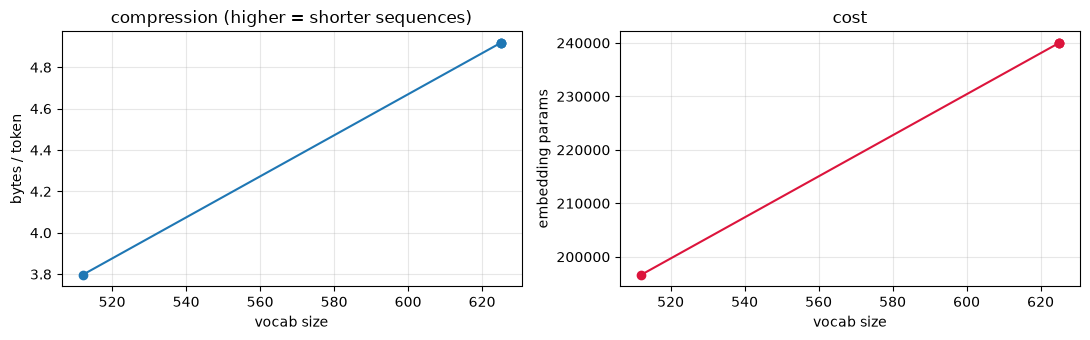

In [14]:
import matplotlib.pyplot as plt
sample = texts[0][:20000]
sizes, ratios, params = [], [], []
D_MODEL = 384
for v in [512, 1024, 2048, 4096]:
    t = BPETokenizer.train([sample], vocab_size=v, verbose=False)
    sizes.append(t.vocab_size); ratios.append(t.compression_ratio(sample))
    params.append(t.vocab_size * D_MODEL)   # tied embedding + head
    print(f'vocab {t.vocab_size:5d} | {ratios[-1]:.2f} bytes/token | embedding params {params[-1]:,}')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(sizes, ratios, 'o-'); ax[0].set_xlabel('vocab size'); ax[0].set_ylabel('bytes / token')
ax[0].set_title('compression (higher = shorter sequences)'); ax[0].grid(alpha=.3)
ax[1].plot(sizes, params, 'o-', color='crimson'); ax[1].set_xlabel('vocab size')
ax[1].set_ylabel('embedding params'); ax[1].set_title('cost'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Test 3 — encoding speed

Encoding replays merges with a linked list + heap (`O(L log L)` per word) and
an LRU cache at the word level. Because word frequency is Zipfian, the cache
hit rate on real text is very high, so throughput is far above the
cache-cold number.

In [15]:
big = texts[0][:200000]
t0=time.time(); ids = tok.encode(big); cold = time.time()-t0
t0=time.time(); ids = tok.encode(big); warm = time.time()-t0
print(f'cold: {len(big)/cold/1e6:.2f} MB/s | warm (LRU cache): {len(big)/warm/1e6:.2f} MB/s')
print(f'speedup from word-level caching: {cold/warm:.1f}x')

cold: 2.50 MB/s | warm (LRU cache): 3.16 MB/s
speedup from word-level caching: 1.3x


## Inspect what was learned

Merges are ranked by frequency. Early merges are common character pairs; later
merges are whole words and domain terms. If you do not see domain vocabulary
("chief executive", "filing") in the later merges, your corpus is too small or
off-domain.

In [16]:
by_rank = sorted(tok.merges.items(), key=lambda kv: kv[1])
print('first 15 merges (most frequent pairs):')
for (a,b), r in by_rank[:15]:
    print(f'  {r:4d}: {tok.vocab[a]!r} + {tok.vocab[b]!r} -> {tok.vocab[256+r]!r}')
print('\nlast 10 merges (rarest / longest):')
for (a,b), r in by_rank[-10:]:
    print(f'  {r:4d}: -> {tok.vocab[256+r]!r}')

first 15 merges (most frequent pairs):
     0: b'a' + b'n' -> b'an'
     1: b'i' + b'n' -> b'in'
     2: b'i' + b'e' -> b'ie'
     3: b't' + b'i' -> b'ti'
     4: b' ' + b'c' -> b' c'
     5: b'e' + b'd' -> b'ed'
     6: b'0' + b'2' -> b'02'
     7: b'2' + b'02' -> b'202'
     8: b' ' + b'A' -> b' A'
     9: b' ' + b't' -> b' t'
    10: b'm' + b'e' -> b'me'
    11: b' ' + b'o' -> b' o'
    12: b's' + b't' -> b'st'
    13: b' ' + b'a' -> b' a'
    14: b'e' + b'c' -> b'ec'

last 10 merges (rarest / longest):
   348: -> b' over'
   349: -> b' expected'
   350: -> b' regulator'
   351: -> b' revenue'
   352: -> b' approval'
   353: -> b' phase'
   354: -> b' acquired'
   355: -> b' guidance'
   356: -> b' regulatory'
   357: -> b'?Acme'


In [9]:
out = ROOT/'checkpoints'/'tokenizer.json'
tok.save(out)
print('saved ->', out)
reloaded = BPETokenizer.load(out)
assert reloaded.encode('Acme 2026') == tok.encode('Acme 2026')
print('reload verified — notebook 02 will use this file')

saved -> C:\VERITAS\checkpoints\tokenizer.json
reload verified — notebook 02 will use this file


## Design trade-offs to be able to defend

1. **Vocab size.** Small vocab → longer sequences → attention cost grows
   quadratically. Large vocab → most of the parameter budget sits in the
   embedding, and rare tokens get too few gradient updates to be learned well.
   4096–8192 is the sweet spot at this model scale.
2. **`min_frequency`.** Raising it drops hapax words and shrinks the merge
   search, at the cost of splitting rare entity names into more pieces.
3. **Pre-tokenization regex.** It forbids merges *across* its boundaries. The
   GPT-4-style pattern keeps a leading space attached to a word (` the`), which
   halves the token count of ordinary prose versus splitting the space off.
4. **Why not `tokenizers`/`sentencepiece`?** They are faster (Rust), and in
   production you would use them. Implementing it makes the merge ordering,
   the cost model, and the `<unk>` argument above yours to explain.

Next: **02 — the Transformer.**